In [4]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

GPU available: True
GPU name: Tesla T4


In [5]:
!pip install transformers datasets evaluate accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
import evaluate
import os

Connect Colab to drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Verify Colab can see my files

In [8]:
import os
acdc_path = "/content/drive/MyDrive/ACDC"
print(os.listdir(acdc_path))

['gt_trainval.zip', 'rgb_anon_trainvaltest.zip']


Unzip the dataset

In [9]:
import zipfile

print("Unzipping images...")
with zipfile.ZipFile(f"{acdc_path}/rgb_anon_trainvaltest.zip", 'r') as z:
    z.extractall("/content/acdc")

print("Unzipping labels...")
with zipfile.ZipFile(f"{acdc_path}/gt_trainval.zip", 'r') as z:
    z.extractall("/content/acdc")

print("Done!")

Unzipping images...
Unzipping labels...
Done!


Verify the dataset

Foggy training images: 400
Foggy training labels: 0


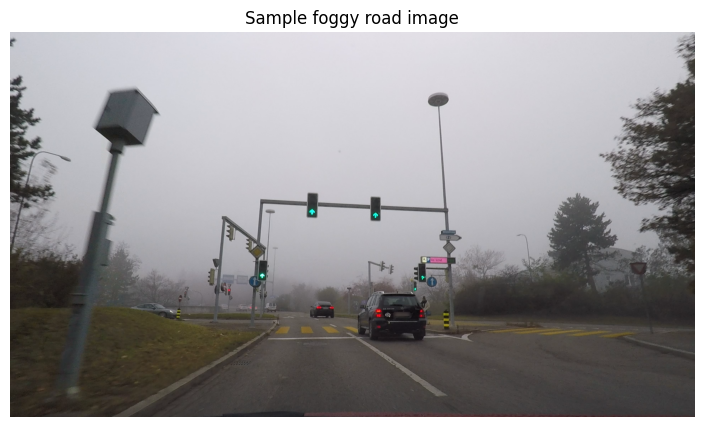

In [11]:
fog_images = list(Path("/content/acdc/rgb_anon/fog/train").rglob("*.png"))
fog_labels = list(Path("/content/acdc/gt/fog/train").rglob("*.png"))

print(f"Foggy training images: {len(fog_images)}")
print(f"Foggy training labels: {len(fog_labels)}")

# Display a sample image
img = np.array(Image.open(fog_images[0]))
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.title("Sample foggy road image")
plt.axis("off")
plt.show()

In [19]:
fog_labels = list(Path("/content/acdc/gt_trainval/gt/fog/train").rglob("*_gt_labelTrainIds.png"))
print(f"Foggy training labels: {len(fog_labels)}")

Foggy training labels: 400


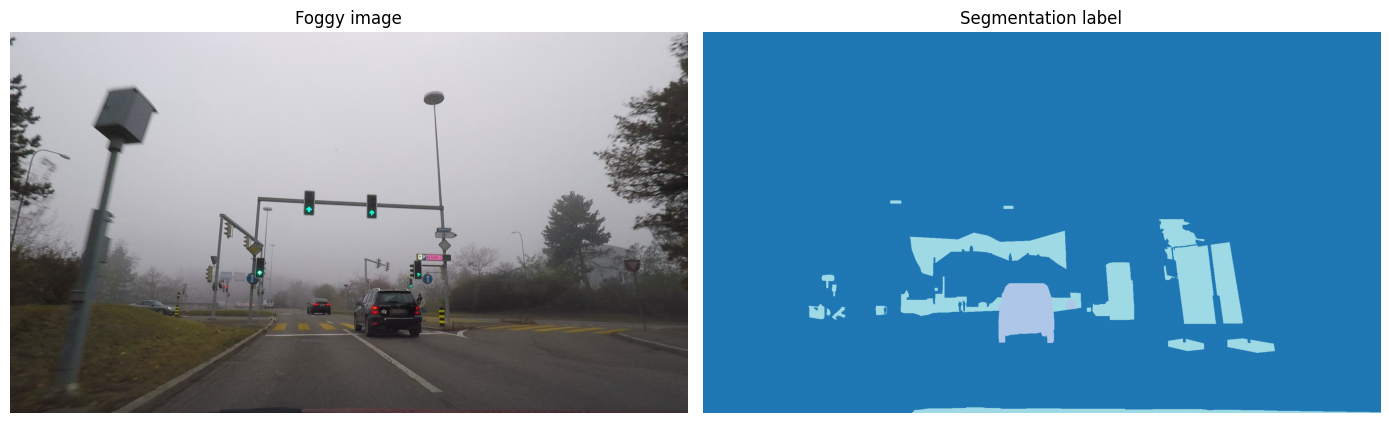

In [20]:
img = Image.open(fog_images[0]).convert("RGB")
label = Image.open(fog_labels[0])

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Foggy image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(label, cmap="tab20")
plt.title("Segmentation label")
plt.axis("off")

plt.tight_layout()
plt.show()

Load SegFormer

In [22]:
# download and load the pre-trained model
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

model_name = "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"

processor = SegformerImageProcessor.from_pretrained(model_name)
model = SegformerForSemanticSegmentation.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model loaded on: {device}")
print(f"Number of classes: {model.config.num_labels}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/14.9M [00:00<?, ?B/s]

Model loaded on: cuda
Number of classes: 19


Cityscapes colors and respective classes

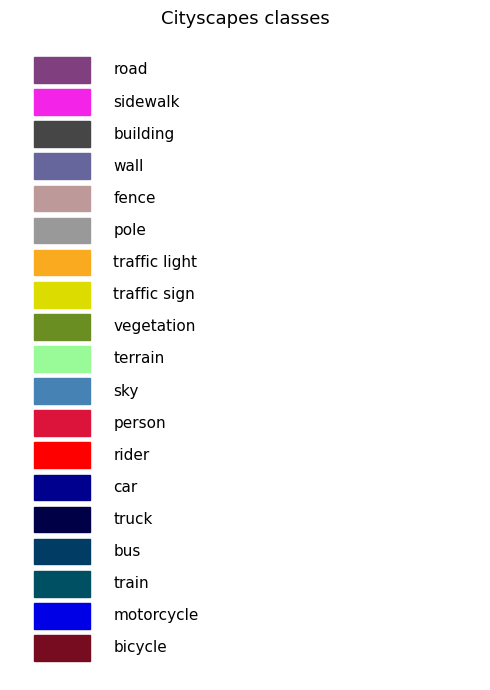

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(5, 7))
ax.axis("off")

for i, (name, color) in enumerate(zip(CLASS_NAMES, CITYSCAPES_COLORS)):
    y = 1 - (i + 1) / (len(CLASS_NAMES) + 1)
    # Color box
    ax.add_patch(plt.Rectangle((0.05, y - 0.02), 0.12, 0.04,
                                color=color/255.0, transform=ax.transAxes))
    # Class name
    ax.text(0.22, y, name, transform=ax.transAxes,
            fontsize=11, va="center", color="black")

plt.title("Cityscapes classes", fontsize=13, pad=10)
plt.tight_layout()
plt.show()

Run Inference on one foggy image

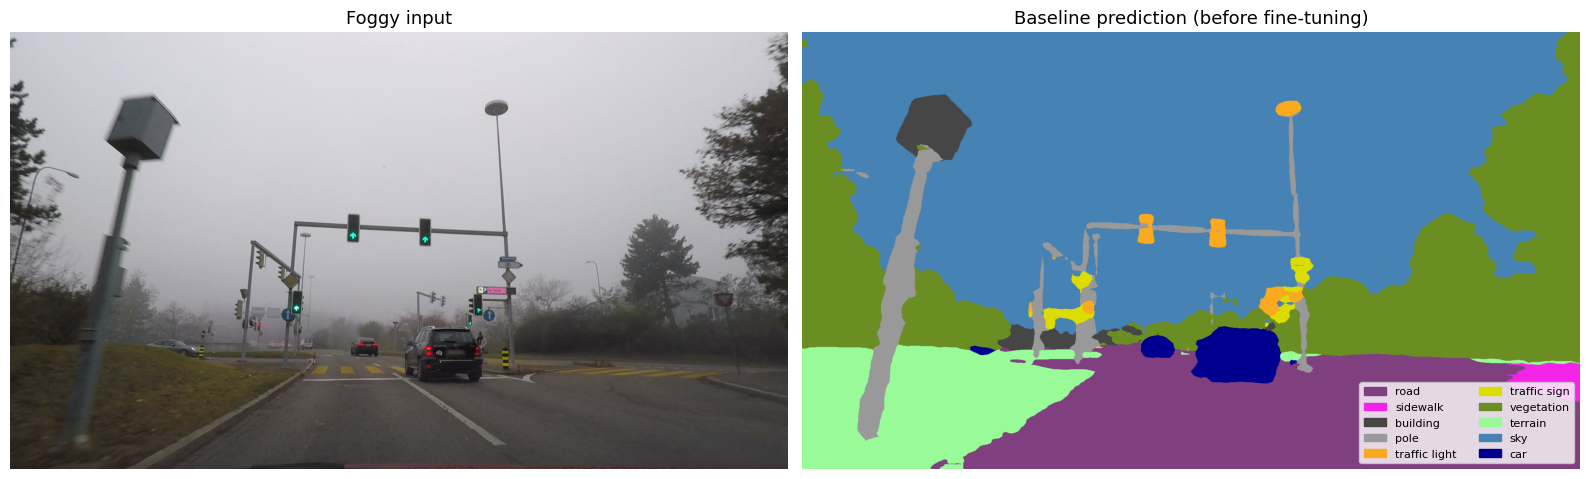

Saved to /content/baseline_prediction.png


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# Official Cityscapes color map (19 train classes)
CITYSCAPES_COLORS = np.array([
    [128,  64, 128],  # 0  road
    [244,  35, 232],  # 1  sidewalk
    [ 70,  70,  70],  # 2  building
    [102, 102, 156],  # 3  wall
    [190, 153, 153],  # 4  fence
    [153, 153, 153],  # 5  pole
    [250, 170,  30],  # 6  traffic light
    [220, 220,   0],  # 7  traffic sign
    [107, 142,  35],  # 8  vegetation
    [152, 251, 152],  # 9  terrain
    [ 70, 130, 180],  # 10 sky
    [220,  20,  60],  # 11 person
    [255,   0,   0],  # 12 rider
    [  0,   0, 142],  # 13 car
    [  0,   0,  70],  # 14 truck
    [  0,  60, 100],  # 15 bus
    [  0,  80, 100],  # 16 train
    [  0,   0, 230],  # 17 motorcycle
    [119,  11,  32],  # 18 bicycle
], dtype=np.uint8)

CLASS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation", "terrain",
    "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]

def colorize_prediction(pred):
    """Convert class index map to RGB color image"""
    h, w = pred.shape
    color_img = np.zeros((h, w, 3), dtype=np.uint8)
    for class_idx, color in enumerate(CITYSCAPES_COLORS):
        color_img[pred == class_idx] = color
    return color_img

def visualize_with_legend(image_path):
    image, pred = run_inference(image_path)
    colored_pred = colorize_prediction(pred)

    # Find which classes are actually present in this prediction
    present_classes = np.unique(pred)
    present_classes = present_classes[present_classes < 19]

    # Build legend only for present classes
    patches = [
        mpatches.Patch(
            color=CITYSCAPES_COLORS[i] / 255.0,
            label=CLASS_NAMES[i]
        )
        for i in present_classes
    ]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].imshow(image)
    axes[0].set_title("Foggy input", fontsize=13)
    axes[0].axis("off")

    axes[1].imshow(colored_pred)
    axes[1].set_title("Baseline prediction (before fine-tuning)", fontsize=13)
    axes[1].axis("off")
    axes[1].legend(
        handles=patches,
        loc="lower right",
        fontsize=8,
        ncol=2,
        framealpha=0.8
    )

    plt.tight_layout()
    plt.savefig("/content/baseline_prediction.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to /content/baseline_prediction.png")

# Run it
visualize_with_legend(fog_images[0])

Training

In [32]:
# Define ACDCDataset
from torch.utils.data import Dataset, DataLoader

class ACDCDataset(Dataset):
    def __init__(self, image_dir, label_dir, processor):
        self.images = sorted(Path(image_dir).rglob("*.png"))
        self.labels = sorted(Path(label_dir).rglob("*_gt_labelTrainIds.png"))
        self.processor = processor
        assert len(self.images) == len(self.labels), \
            f"Mismatch: {len(self.images)} images but {len(self.labels)} labels"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        label = Image.open(self.labels[idx])
        encoded = self.processor(
            images=image,
            segmentation_maps=label,
            return_tensors="pt"
        )
        return {k: v.squeeze() for k, v in encoded.items()}

print("ACDCDataset class defined!")

ACDCDataset class defined!


In [33]:
# Create the Dataset
train_dataset = ACDCDataset(
    image_dir="/content/acdc/rgb_anon/fog/train",
    label_dir="/content/acdc/gt_trainval/gt/fog/train",
    processor=processor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

print(f"Training samples: {len(train_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

Training samples: 400
Batches per epoch: 100


In [34]:
# Set up training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=6e-5)

print(f"Training on: {device}")
print("Starting training...")

Training on: cuda
Starting training...


In [35]:
# Train for 10 epochs
for epoch in range(10):
    model.train()
    total_loss = 0

    for i, batch in enumerate(train_loader):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        # Print progress every 20 batches
        if (i + 1) % 20 == 0:
            print(f"  Epoch {epoch+1} | Batch {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/10 complete — Avg Loss: {avg_loss:.4f}")
    print("-" * 50)

print("Training complete!")

  Epoch 1 | Batch 20/100 | Loss: 0.1690
  Epoch 1 | Batch 40/100 | Loss: 0.1916
  Epoch 1 | Batch 60/100 | Loss: 0.2305
  Epoch 1 | Batch 80/100 | Loss: 0.1683
  Epoch 1 | Batch 100/100 | Loss: 0.2139
Epoch 1/10 complete — Avg Loss: 0.2503
--------------------------------------------------
  Epoch 2 | Batch 20/100 | Loss: 0.2399
  Epoch 2 | Batch 40/100 | Loss: 0.1331
  Epoch 2 | Batch 60/100 | Loss: 0.1881
  Epoch 2 | Batch 80/100 | Loss: 0.1376
  Epoch 2 | Batch 100/100 | Loss: 0.2469
Epoch 2/10 complete — Avg Loss: 0.1688
--------------------------------------------------
  Epoch 3 | Batch 20/100 | Loss: 0.1293
  Epoch 3 | Batch 40/100 | Loss: 0.1691
  Epoch 3 | Batch 60/100 | Loss: 0.1496
  Epoch 3 | Batch 80/100 | Loss: 0.0999
  Epoch 3 | Batch 100/100 | Loss: 0.1798
Epoch 3/10 complete — Avg Loss: 0.1457
--------------------------------------------------
  Epoch 4 | Batch 20/100 | Loss: 0.0773
  Epoch 4 | Batch 40/100 | Loss: 0.1367
  Epoch 4 | Batch 60/100 | Loss: 0.1416
  Epoch

Save

In [36]:
import os
os.makedirs("/content/drive/MyDrive/ACDC/model", exist_ok=True)

model.save_pretrained("/content/drive/MyDrive/ACDC/model")
processor.save_pretrained("/content/drive/MyDrive/ACDC/model")

print("Model saved to Google Drive!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to Google Drive!


Results

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

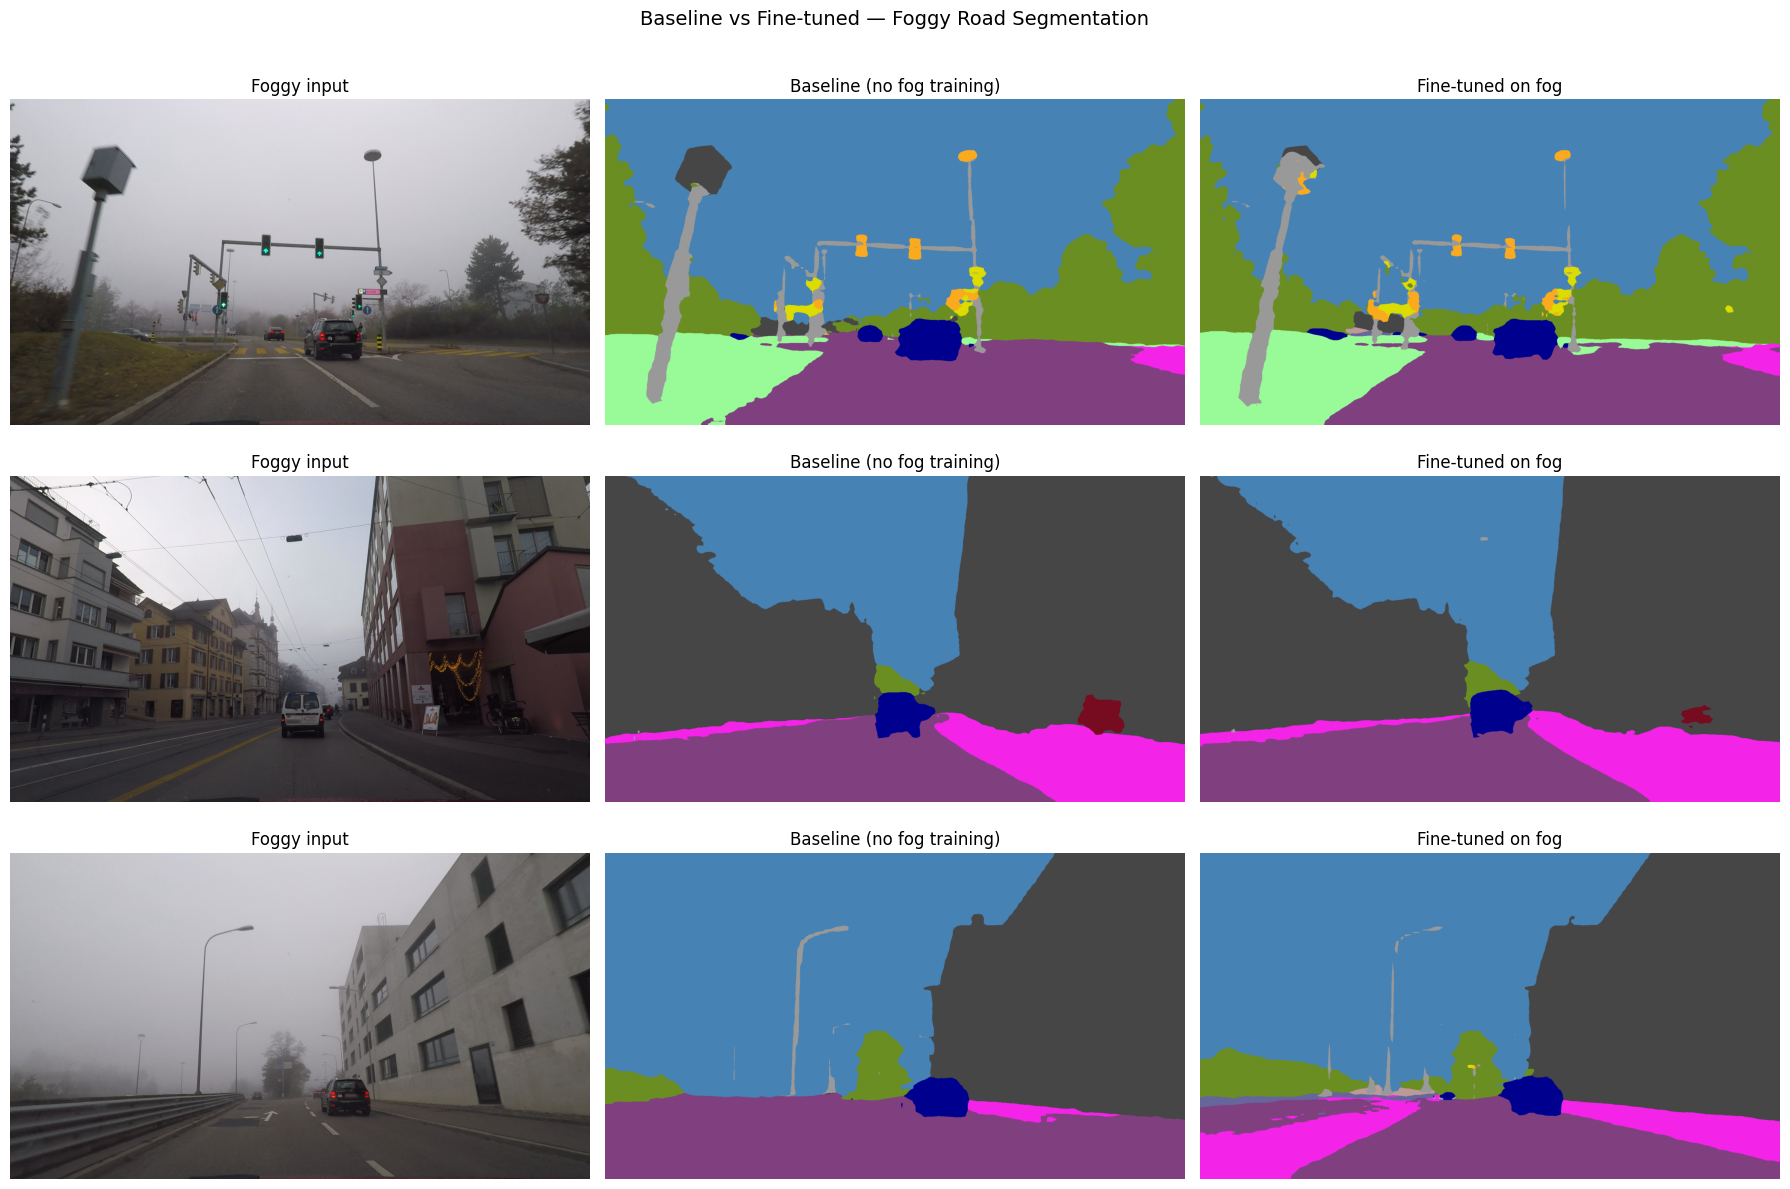

Comparison saved to Drive!


In [37]:
# Compare baseline vs fine-tuned on same foggy image
# Load the fine-tuned model fresh for clean comparison
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

baseline_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"
).to(device)

finetuned_model = SegformerForSemanticSegmentation.from_pretrained(
    "/content/drive/MyDrive/ACDC/model"
).to(device)

def predict(model, image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    upsampled = torch.nn.functional.interpolate(
        logits, size=image.size[::-1],
        mode="bilinear", align_corners=False
    )
    pred = upsampled.argmax(dim=1).squeeze().cpu().numpy()
    return image, pred

# Compare on 3 foggy images
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row, img_path in enumerate(fog_images[:3]):
    image, baseline_pred = predict(baseline_model, img_path)
    _, finetuned_pred = predict(finetuned_model, img_path)

    axes[row, 0].imshow(image)
    axes[row, 0].set_title("Foggy input")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(colorize_prediction(baseline_pred))
    axes[row, 1].set_title("Baseline (no fog training)")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(colorize_prediction(finetuned_pred))
    axes[row, 2].set_title("Fine-tuned on fog")
    axes[row, 2].axis("off")

plt.suptitle("Baseline vs Fine-tuned — Foggy Road Segmentation", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ACDC/comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparison saved to Drive!")

Generate mIoU numbers

In [43]:
import evaluate

metric = evaluate.load("mean_iou")

def compute_miou(model, image_paths, label_paths, num_samples=50):
    model.eval()
    with torch.no_grad():
        for img_path, lbl_path in zip(image_paths[:num_samples], label_paths[:num_samples]):
            image = Image.open(img_path).convert("RGB")
            label = np.array(Image.open(lbl_path))

            inputs = processor(images=image, return_tensors="pt").to(device)
            outputs = model(**inputs)

            upsampled = torch.nn.functional.interpolate(
                outputs.logits,
                size=label.shape,
                mode="bilinear",
                align_corners=False
            )
            pred = upsampled.argmax(dim=1).squeeze().cpu().numpy()

            metric.add_batch(
                predictions=[pred],
                references=[label]
            )

    results = metric.compute(
        num_labels=19,
        ignore_index=255,
        reduce_labels=False
    )
    return results["mean_iou"]

# Get all test images and labels
fog_val_images = sorted(Path("/content/acdc/rgb_anon/fog/val").rglob("*.png"))
fog_val_labels = sorted(Path("/content/acdc/gt_trainval/gt/fog/val").rglob("*_gt_labelTrainIds.png"))

print(f"Val images: {len(fog_val_images)}")
print(f"Val labels: {len(fog_val_labels)}")

print("Evaluating baseline model...")
baseline_miou = compute_miou(baseline_model, fog_val_images, fog_val_labels)
print(f"Baseline mIoU: {baseline_miou:.4f}")

print("\nEvaluating fine-tuned model...")
finetuned_miou = compute_miou(finetuned_model, fog_val_images, fog_val_labels)
print(f"Fine-tuned mIoU: {finetuned_miou:.4f}")

improvement = ((finetuned_miou - baseline_miou) / baseline_miou) * 100
print(f"\nImprovement: +{improvement:.1f}%")

Val images: 100
Val labels: 100
Evaluating baseline model...


/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


Baseline mIoU: 0.5452

Evaluating fine-tuned model...
Fine-tuned mIoU: 0.6055

Improvement: +11.1%


Result visualization

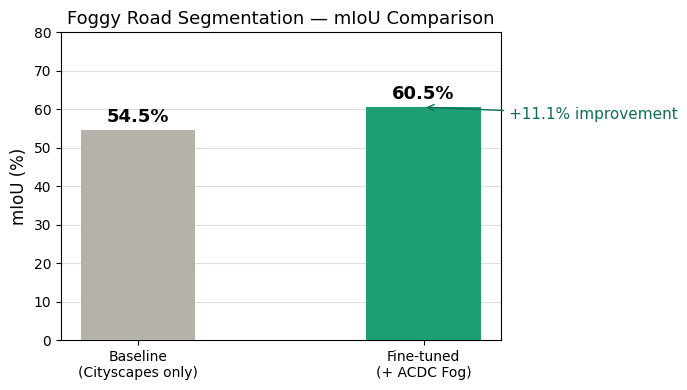

Saved to Drive!


In [44]:
fig, ax = plt.subplots(figsize=(7, 4))

models = ["Baseline\n(Cityscapes only)", "Fine-tuned\n(+ ACDC Fog)"]
scores = [baseline_miou * 100, finetuned_miou * 100]
colors = ["#B4B2A9", "#1D9E75"]

bars = ax.bar(models, scores, color=colors, width=0.4, zorder=3)
ax.set_ylim(0, 80)
ax.set_ylabel("mIoU (%)", fontsize=12)
ax.set_title("Foggy Road Segmentation — mIoU Comparison", fontsize=13)
ax.yaxis.grid(True, zorder=0, alpha=0.4)
ax.set_axisbelow(True)

for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{score:.1f}%",
        ha="center", va="bottom", fontsize=13, fontweight="bold"
    )

ax.annotate(
    f"+11.1% improvement",
    xy=(1, finetuned_miou * 100),
    xytext=(1.3, (baseline_miou + finetuned_miou) * 50),
    fontsize=11, color="#0F6E56",
    arrowprops=dict(arrowstyle="->", color="#0F6E56")
)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ACDC/miou_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to Drive!")

In [45]:
import shutil

output_files = [
    "/content/baseline_prediction.png",
    "/content/drive/MyDrive/ACDC/comparison.png",
    "/content/drive/MyDrive/ACDC/miou_results.png"
]

for f in output_files:
    print(f"Saved: {f}")

print("\nAll results are in your Google Drive under ACDC/")
print("Download them to your laptop for the GitHub repo")

Saved: /content/baseline_prediction.png
Saved: /content/drive/MyDrive/ACDC/comparison.png
Saved: /content/drive/MyDrive/ACDC/miou_results.png

All results are in your Google Drive under ACDC/
Download them to your laptop for the GitHub repo
